# Maps of coordination by département — 2002 & 2022

## 1. Purpose

Three département-level map figures for the 96 metropolitan départements (Corsica in place, no overseas territories,
Lambert-93 projection):

| figure | content |
|---|---|
| 1 | CENP in 2002 and 2022, shared colour scale |
| 2 | `delta_CENP = CENP_2022 − CENP_2002` |
| 3 | 2022 residuals of the descriptive regression `CENP ~ log_density` |

Reads `data/processed/coordination_density_departements.csv` and `..._wide.csv` (built by `scripts/01`–`04`) and a
département boundary file (not in the repository — see §2). Nothing is written to `data/`; figures go to `figures/`.
Everything is **descriptive**. The cliff measures are not mapped here; they are shown in the interactive explorer
(`scripts/build_department_explorer.py`).

## 2. Imports and paths

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # only for the 'rocket_r' colormap
import statsmodels.formula.api as smf
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm, to_hex
from matplotlib.ticker import FuncFormatter, MaxNLocator

from svgeo.config import DEPARTMENT_DENSITY, DEPARTMENT_DENSITY_WIDE, METRO_CODES, RAW_DIR, ROOT, YEARS
from svgeo.utils import read_csv, report, show

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [2]:
# ---- Configuration: département boundaries ----
# Built from RAW_DIR (= <repo>/data/raw), so it works whatever folder the notebook runs from.
DEPARTMENTS_BOUNDARIES_PATH = RAW_DIR / "geography" / "departements-100m.geojson"
# Column of that file holding the département code ('01', '2A', …). None = detect it from common names below.
GEOMETRY_CODE_COLUMN = None
CODE_COLUMN_CANDIDATES = ["department_code", "code", "code_insee", "INSEE_DEP", "insee_dep", "CODE_DEPT",
                          "code_dept", "code_dep", "DEP", "dep"]

# ---- Output ----
FIGURES_DIR = ROOT / "figures"
LAMBERT_93 = "EPSG:2154"

# ---- Report style ----
INK, MUTED, FAINT = "#1a1a1a", "#5f6368", "#8a8f94"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
ALPHA = 0.9
BORDERS = {"edgecolor": "white", "linewidth": 0.35}  # thin light borders between départements
SINGLE_MAP_WIDTH = 6.6   # inches of map (France only) in the single-panel figures
DOUBLE_MAP_WIDTH = 5.2   # inches of map per panel in the two-panel figures
CALLOUT_GUTTER = 0.24    # width of each side gutter for callout labels, as a share of the map width
CALLOUT_REFERENCE_CODES = ["75"]  # also labelled in figure 2 if not already among the extremes (Paris)
# Side of the map for specific callouts (default: the side the département is on). Paris goes right so that its
# leader line stays horizontal instead of crossing the map towards the other left-hand labels.
CALLOUT_SIDES = {"75": "right"}
SOURCE_NOTE = ("Sources: Ministère de l'Intérieur (first-round results), INSEE (population, surface). "
               "96 metropolitan départements.")

CMAP_LEVELS = sns.color_palette("rocket_r", as_cmap=True)  # light = low CENP, dark = high CENP (more coordination)
CMAP_DIVERGING = plt.get_cmap("Spectral_r")

CLIFF_CATEGORIES = ["1", "2", "3", "4", "5+"]  # grouped cliff location (validated below, mapped in the explorer)

FIGURES = {}  # file name (without extension) -> matplotlib figure, saved in §11

## 3. Load département analysis data

Long file: one row per year × département (`in_main_sample` = the 96 metropolitan départements). Wide file: one row
per metropolitan département with `CENP_2002`, `CENP_2022` and `delta_CENP`.

In [3]:
def prepare_metropolitan_departments(df, label):
    """Keep the 96 metropolitan départements; every dropped code is printed, nothing is dropped silently."""
    is_metro = df["department_code"].isin(METRO_CODES)
    dropped = sorted(df.loc[~is_metro, "department_code"].astype(str).unique())
    print(f"{label}: {is_metro.sum()} metropolitan rows kept; {len(dropped)} non-metropolitan codes dropped: {dropped}")
    return df[is_metro].copy()


def group_cliff_location(values):
    """cliff_location -> ordered categories '1', '2', '3', '4', '5+' (NaN stays NaN)."""
    return pd.cut(values, bins=[0.5, 1.5, 2.5, 3.5, 4.5, np.inf], labels=CLIFF_CATEGORIES, ordered=True)


long = read_csv(DEPARTMENT_DENSITY)
wide = read_csv(DEPARTMENT_DENSITY_WIDE)

dep = prepare_metropolitan_departments(long, "long file")
dep["cliff_group"] = group_cliff_location(dep["cliff_location"])
wide = prepare_metropolitan_departments(wide, "wide file")

show(dep.groupby("year")[["CENP", "cliff_location", "density", "log_density"]].describe().T)
print("cliff_location grouped (not mapped here; shown in the interactive explorer):")
show(pd.crosstab(dep["year"], dep["cliff_group"], dropna=False))

long file: 192 metropolitan rows kept; 11 non-metropolitan codes dropped: ['971', '972', '973', '974', '975', '976', '986', '987', '988', 'ZX', 'ZZ']
wide file: 96 metropolitan rows kept; 0 non-metropolitan codes dropped: []


year                          2002          2022
CENP           count     96.000000     96.000000
               mean       0.507290      0.621994
               std        0.043391      0.043344
               min        0.383258      0.526279
               25%        0.484082      0.594651
               50%        0.500046      0.622931
               75%        0.528644      0.646132
               max        0.675161      0.789987
cliff_location count     96.000000     96.000000
               mean       2.437500      2.541667
               std        0.792232      0.752773
               min        1.000000      1.000000
               25%        2.000000      2.000000
               50%        3.000000      3.000000
               75%        3.000000      3.000000
               max        4.000000      3.000000
density        count     96.000000     96.000000
               mean     529.260736    566.654391
               std     2347.918643   2400.542511
               min       14.487853     14.806421
               25%       48.906122     49.910675
               50%       78.610564     83.420990
               75%      150.242228    168.187789
               max    20355.521822  20054.127135
log_density    count     96.000000     96.000000
               mean       4.586577      4.666628
               std        1.232058      1.252734
               min        2.673311      2.695061
               25%        3.889847      3.909360
               50%        4.364239      4.423900
               75%        5.012241      5.125077
               max        9.921107      9.906190

cliff_location grouped (not mapped here; shown in the interactive explorer):


cliff_group,1,2,3,4,5+
year,,,,,
2002,17,21,57,1,0
2022,15,14,67,0,0


## 4. Load département geometry

The file must contain metropolitan département boundaries and a département-code column. Its columns are printed
first; if the code column is not detected, set `GEOMETRY_CODE_COLUMN` in §2. Codes are kept as text ('01', '2A', '2B');
one-digit numeric codes are zero-padded. Several features with the same code (e.g. islands stored separately) are
dissolved into one. The geometry is reprojected to Lambert-93.

In [4]:
def normalise_department_code(values):
    """'1' -> '01', '2a' -> '2A'; codes stay text."""
    codes = values.astype(str).str.strip().str.upper()
    return codes.where(~codes.str.fullmatch(r"\d"), codes.str.zfill(2))


def load_department_geometry(path=DEPARTMENTS_BOUNDARIES_PATH, code_column=GEOMETRY_CODE_COLUMN):
    """GeoDataFrame with `department_code` (text) and `geometry`, in Lambert-93."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No boundary file at {path} — set DEPARTMENTS_BOUNDARIES_PATH in §2.")
    geo = gpd.read_file(path)
    print(f"{path.name}: {len(geo)} features, CRS = {geo.crs}")
    print("Columns:", list(geo.columns))
    show(geo.drop(columns="geometry").head())

    if code_column is None:
        found = [c for c in CODE_COLUMN_CANDIDATES if c in geo.columns]
        if not found:
            raise KeyError("No département-code column recognised — set GEOMETRY_CODE_COLUMN in §2.")
        code_column = found[0]
    print(f"Département code column: {code_column!r}")

    geo = geo[[code_column, "geometry"]].rename(columns={code_column: "department_code"})
    geo["department_code"] = normalise_department_code(geo["department_code"])
    duplicated = geo["department_code"].duplicated(keep=False)
    if duplicated.any():
        print(f"{duplicated.sum()} features share a code — dissolved:",
              sorted(geo.loc[duplicated, "department_code"].unique()))
        geo = geo.dissolve(by="department_code", as_index=False)

    if geo.crs is None:
        raise ValueError("The boundary file has no CRS: set it with geo.set_crs(...) before reprojecting.")
    return geo.to_crs(LAMBERT_93)


geo_all = load_department_geometry()
geo = prepare_metropolitan_departments(geo_all, "geometry")

departements-100m.geojson: 109 features, CRS = EPSG:4326
Columns: ['code', 'nom', 'region', 'geometry']


,code,nom,region
0,01,Ain,84
1,02,Aisne,32
2,03,Allier,84
3,04,Alpes-de-Haute-Provence,93
4,05,Hautes-Alpes,93


Département code column: 'code'
geometry: 96 metropolitan rows kept; 13 non-metropolitan codes dropped: ['971', '972', '973', '974', '975', '976', '977', '978', '984', '986', '987', '988', '989']


## 5. Clean and merge geographic data

Each map dataset is an **outer** merge of the geometry with the data on `department_code`, with the `_merge`
indicator kept: unmatched codes are printed here and checked in §6, never dropped.

The 2022 residuals (figure 3) are computed here so that §6 can validate them: OLS of `CENP` on `log_density` over the
96 metropolitan départements in 2022, `residual_CENP = CENP − fitted CENP`.

In [5]:
def merge_geometry(geo, data, label):
    """Outer merge geometry ↔ data on department_code, with explicit diagnostics."""
    merged = geo.merge(data, on="department_code", how="outer", validate="one_to_one", indicator=True)
    only_geo = sorted(merged.loc[merged["_merge"] == "left_only", "department_code"])
    only_data = sorted(merged.loc[merged["_merge"] == "right_only", "department_code"])
    print(f"{label}: {(merged['_merge'] == 'both').sum()} matched | geometry only: {only_geo} | data only: {only_data}")
    return merged.sort_values("department_code").reset_index(drop=True)


level_columns = ["department_code", "department_name", "CENP", "cliff_location", "cliff_group", "density",
                 "log_density"]
levels = {year: merge_geometry(geo, dep.loc[dep["year"] == year, level_columns], f"CENP / cliff {year}")
          for year in YEARS}

change = merge_geometry(geo, wide[["department_code", "department_name", "CENP_2002", "CENP_2022", "delta_CENP"]],
                        "delta_CENP")

dep_2022 = dep[dep["year"] == 2022].copy()
residual_fit = smf.ols("CENP ~ log_density", data=dep_2022).fit()
dep_2022["fitted_CENP"] = residual_fit.fittedvalues
dep_2022["residual_CENP"] = dep_2022["CENP"] - dep_2022["fitted_CENP"]
residuals = merge_geometry(geo, dep_2022[["department_code", "department_name", "CENP", "log_density", "fitted_CENP",
                                          "residual_CENP"]], "residuals 2022")

CENP / cliff 2002: 96 matched | geometry only: [] | data only: []
CENP / cliff 2022: 96 matched | geometry only: [] | data only: []
delta_CENP: 96 matched | geometry only: [] | data only: []
residuals 2022: 96 matched | geometry only: [] | data only: []


## 6. Validate merges

In [6]:
for year in YEARS:
    d = dep[dep["year"] == year]
    report(f"{year}: exactly the 96 metropolitan départements in the data",
           len(d) == 96 and set(d["department_code"]) == set(METRO_CODES))
    report(f"{year}: department_code unique", not d["department_code"].duplicated().any(),
           d[d["department_code"].duplicated(keep=False)])
report("wide: 96 metropolitan départements, codes unique",
       len(wide) == 96 and set(wide["department_code"]) == set(METRO_CODES) and wide["department_code"].is_unique)
report("delta_CENP = CENP_2022 − CENP_2002", np.allclose(wide["delta_CENP"], wide["CENP_2022"] - wide["CENP_2002"]))
report("geometry: codes unique", geo["department_code"].is_unique)
report(f"geometry: CRS is {LAMBERT_93}", geo.crs.to_epsg() == 2154)

[OK] 2002: exactly the 96 metropolitan départements in the data
[OK] 2002: department_code unique
[OK] 2022: exactly the 96 metropolitan départements in the data
[OK] 2022: department_code unique
[OK] wide: 96 metropolitan départements, codes unique
[OK] delta_CENP = CENP_2022 − CENP_2002
[OK] geometry: codes unique
[OK] geometry: CRS is EPSG:2154


In [7]:
map_datasets = {
    "figure 1 — CENP 2002": (levels[2002], ["CENP"]),
    "figure 1 — CENP 2022": (levels[2022], ["CENP"]),
    "figure 2 — delta_CENP": (change, ["delta_CENP"]),
    "figure 3 — residual CENP 2022": (residuals, ["residual_CENP"]),
    "cliff location 2002 (explorer)": (levels[2002], ["cliff_group"]),
    "cliff location 2022 (explorer)": (levels[2022], ["cliff_group"]),
}
problems = []
for name, (gdf, columns) in map_datasets.items():
    unmatched = gdf["_merge"] != "both"
    complete = len(gdf) == 96 and set(gdf["department_code"]) == set(METRO_CODES)
    missing = gdf[columns].isna().any(axis=1) | gdf.geometry.isna() | gdf.geometry.is_empty
    report(f"{name}: every département matched geometry ↔ data", not unmatched.any(),
           gdf.loc[unmatched, ["department_code", "_merge"]])
    report(f"{name}: exactly the 96 metropolitan départements", complete)
    report(f"{name}: no missing {columns} or geometry", not missing.any(),
           gdf.loc[missing, ["department_code", *columns]])
    if unmatched.any() or not complete or missing.any():
        problems.append(name)
assert not problems, f"Fix these map datasets before plotting: {problems}"

[OK] figure 1 — CENP 2002: every département matched geometry ↔ data
[OK] figure 1 — CENP 2002: exactly the 96 metropolitan départements
[OK] figure 1 — CENP 2002: no missing ['CENP'] or geometry
[OK] figure 1 — CENP 2022: every département matched geometry ↔ data
[OK] figure 1 — CENP 2022: exactly the 96 metropolitan départements
[OK] figure 1 — CENP 2022: no missing ['CENP'] or geometry
[OK] figure 2 — delta_CENP: every département matched geometry ↔ data
[OK] figure 2 — delta_CENP: exactly the 96 metropolitan départements
[OK] figure 2 — delta_CENP: no missing ['delta_CENP'] or geometry
[OK] figure 3 — residual CENP 2022: every département matched geometry ↔ data
[OK] figure 3 — residual CENP 2022: exactly the 96 metropolitan départements
[OK] figure 3 — residual CENP 2022: no missing ['residual_CENP'] or geometry
[OK] cliff location 2002 (explorer): every département matched geometry ↔ data
[OK] cliff location 2002 (explorer): exactly the 96 metropolitan départements
[OK] cliff loc

### Plotting helpers

Every figure uses the same frame: a left-aligned title and subtitle, maps of identical extent (Lambert-93 bounds of
metropolitan France, Corsica included) sized to the canvas, a legend strip below the maps and a small note. Sizes are
set in inches, so the maps fill the canvas without the white space of automatic layouts.

In [8]:
def map_extent(gutter=0.0, pad=0.02):
    """(xmin, xmax, ymin, ymax) of metropolitan France in Lambert-93, with optional side gutters for callouts."""
    xmin, ymin, xmax, ymax = geo.total_bounds
    width, height = xmax - xmin, ymax - ymin
    return (xmin - (pad + gutter) * width, xmax + (pad + gutter) * width, ymin - pad * height, ymax + pad * height)


def report_figure(title, subtitle, n_panels=1, map_width=SINGLE_MAP_WIDTH, gutter=0.0, panel_headers=False,
                  legend_height=0.8, note=SOURCE_NOTE):
    """Figure with a title block, `n_panels` map axes of identical extent, a legend strip and a note.

    Returns (fig, axes, legend_box) — legend_box = (left, bottom, width, height) in figure fractions.
    """
    x0, x1, y0, y1 = map_extent(gutter)
    france_x0, france_x1, _, _ = map_extent()
    axes_w = map_width * (x1 - x0) / (france_x1 - france_x0)
    axes_h = axes_w * (y1 - y0) / (x1 - x0)
    margin, gap, header = 0.35, 0.3, 1.0
    panel_header = 0.34 if panel_headers else 0.0
    footer = 0.2 + 0.15 * (note.count("\n") + 1) if note else 0.15

    fig_w = 2 * margin + n_panels * axes_w + (n_panels - 1) * gap
    fig_h = header + panel_header + axes_h + legend_height + footer
    fig = plt.figure(figsize=(fig_w, fig_h))
    fig.text(margin / fig_w, 1 - 0.28 / fig_h, title, fontsize=16, fontweight="bold", va="top")
    fig.text(margin / fig_w, 1 - 0.66 / fig_h, subtitle, fontsize=10.5, color=MUTED, va="top")
    if note:
        fig.text(margin / fig_w, 0.14 / fig_h, note, fontsize=7.5, color=FAINT, va="bottom", linespacing=1.4)

    axes = []
    bottom = footer + legend_height
    for i in range(n_panels):
        left = margin + i * (axes_w + gap)
        ax = fig.add_axes([left / fig_w, bottom / fig_h, axes_w / fig_w, axes_h / fig_h])
        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)
        ax.set_aspect("equal")
        ax.set_axis_off()
        axes.append(ax)
    legend_box = (margin / fig_w, footer / fig_h, (fig_w - 2 * margin) / fig_w, legend_height / fig_h)
    return fig, axes, legend_box


def panel_header(ax, text, right_text=None):
    """Small panel header ('2002') above a map, with an optional muted annotation on the right."""
    ax.annotate(text, (0, 1), xycoords="axes fraction", xytext=(0, 6), textcoords="offset points",
                fontsize=12, fontweight="bold", va="bottom")
    if right_text:
        ax.annotate(right_text, (1, 1), xycoords="axes fraction", xytext=(0, 6), textcoords="offset points",
                    fontsize=9.5, color=MUTED, ha="right", va="bottom")


def signed(value, decimals=2):
    """'+0.31', '−0.15' (true minus sign), '0' when it rounds to zero."""
    if abs(value) < 0.5 * 10 ** -decimals:
        return "0"
    return f"{value:+.{decimals}f}".replace("-", "−")


def _plot_department_colors(gdf, colors, ax):
    """Fill each département with its colour; thin light borders. The axes extent set by report_figure is kept."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    gdf.plot(color=colors, alpha=ALPHA, ax=ax, **BORDERS)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_axis_off()


def plot_continuous_department_map(gdf, column, ax, cmap=CMAP_LEVELS, norm=None):
    """Sequential map; pass a shared `norm` to compare several panels."""
    norm = norm or Normalize(gdf[column].min(), gdf[column].max())
    _plot_department_colors(gdf, [to_hex(c) for c in cmap(norm(gdf[column].to_numpy()))], ax)
    return norm


def symmetric_norm(values):
    """Diverging normalisation centred exactly at 0, limits ± the largest absolute value."""
    limit = np.nanmax(np.abs(values))
    return TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)


def plot_diverging_department_map(gdf, column, ax, cmap=CMAP_DIVERGING):
    norm = symmetric_norm(gdf[column])
    _plot_department_colors(gdf, [to_hex(c) for c in cmap(norm(gdf[column].to_numpy()))], ax)
    return norm


def add_colorbar(fig, legend_box, cmap, norm, label, diverging=False, width=4.2, ends=None):
    """Thin horizontal colour bar centred in the legend strip; label above, ticks below.

    `ends` = (left text, right text) printed under the two ends of the bar (e.g. what negative / positive mean).
    """
    left, bottom, strip_w, strip_h = legend_box
    fig_w, fig_h = fig.get_size_inches()
    bar_w, bar_h = width / fig_w, 0.11 / fig_h
    cax = fig.add_axes([left + (strip_w - bar_w) / 2, bottom + strip_h - 0.42 / fig_h, bar_w, bar_h])
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation="horizontal")
    cbar.solids.set_alpha(ALPHA)
    cbar.outline.set_visible(False)
    cax.set_title(label, fontsize=9.5, color=INK, pad=6)
    cax.tick_params(length=0, labelsize=8.5, pad=4)
    if diverging:
        cax.xaxis.set_major_locator(MaxNLocator(nbins=6, symmetric=True))
        cax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: signed(v)))
    else:
        cax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        cax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
    if ends:
        for x, text, ha in [(0, ends[0], "left"), (1, ends[1], "right")]:
            cax.annotate(text, (x, 0), xycoords="axes fraction",
                         xytext=(0, -22), textcoords="offset points", ha=ha, va="top", fontsize=8, color=MUTED)
    return cbar



def extreme_codes(df, column, n_high=2, n_low=2, extra=()):
    """Codes of the n_high largest and n_low smallest values of `column`, then any `extra` codes not yet included."""
    codes = [*df.nlargest(n_high, column)["department_code"], *df.nsmallest(n_low, column)["department_code"]]
    return codes + [c for c in extra if c not in codes and c in set(df["department_code"])]


def add_callouts(ax, gdf, codes, label, sides=None):
    """Leader-line labels in the side gutters, left or right of France depending on where the département lies.

    `label(code)` returns (name, detail); `detail` may span several lines. `sides` ({code: "left" | "right"}) forces
    the side of specific labels. Labels on one side are stacked from north to south and pushed down when they would
    overlap; a label that is not pushed keeps a horizontal leader line.
    """
    xmin, ymin, xmax, ymax = geo.total_bounds
    centre, offset = (xmin + xmax) / 2, 0.035 * (xmax - xmin)
    points = gdf.set_index("department_code").loc[codes].representative_point()
    y0, y1 = ax.get_ylim()
    data_per_inch = (y1 - y0) / (ax.get_position().height * ax.figure.get_size_inches()[1])

    sides = sides or {}
    side_of = {code: sides.get(code, "left" if p.x < centre else "right") for code, p in points.items()}
    for side in ("left", "right"):
        on_side = sorted(((code, p) for code, p in points.items() if side_of[code] == side),
                         key=lambda item: -item[1].y)
        previous = None  # (label y, number of lines) of the label above
        for code, point in on_side:
            name, detail = label(code)
            n_lines = detail.count("\n") + 2
            y = point.y
            if previous is not None:
                y = min(y, previous[0] - (0.17 * previous[1] + 0.12) * data_per_inch)
            previous = (y, n_lines)
            x, ha = (xmin - offset, "right") if side == "left" else (xmax + offset, "left")
            ax.annotate(name, xy=(point.x, point.y), xytext=(x, y), ha=ha, va="bottom", fontsize=9,
                        fontweight="semibold", color=INK, zorder=6,
                        arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.6, "shrinkA": 0, "shrinkB": 2,
                                    "relpos": (1, 0) if side == "left" else (0, 0)})
            ax.annotate(detail, (x, y), xytext=(0, -2), textcoords="offset points", ha=ha, va="top",
                        fontsize=8.5, color=MUTED, linespacing=1.25, zorder=6)
            ax.plot(point.x, point.y, "o", ms=2.6, color=INK, zorder=7)

## 7. Figure 1 — CENP levels in 2002 and 2022

One colour scale for both panels, from the pooled 2002 and 2022 values. CENP is normalised by the number of
candidates (16 vs 12), but levels are still not strictly comparable across elections; the shared scale shows the
overall shift as well as the geography within each year. Panel headers give the unweighted mean over the 96
départements.

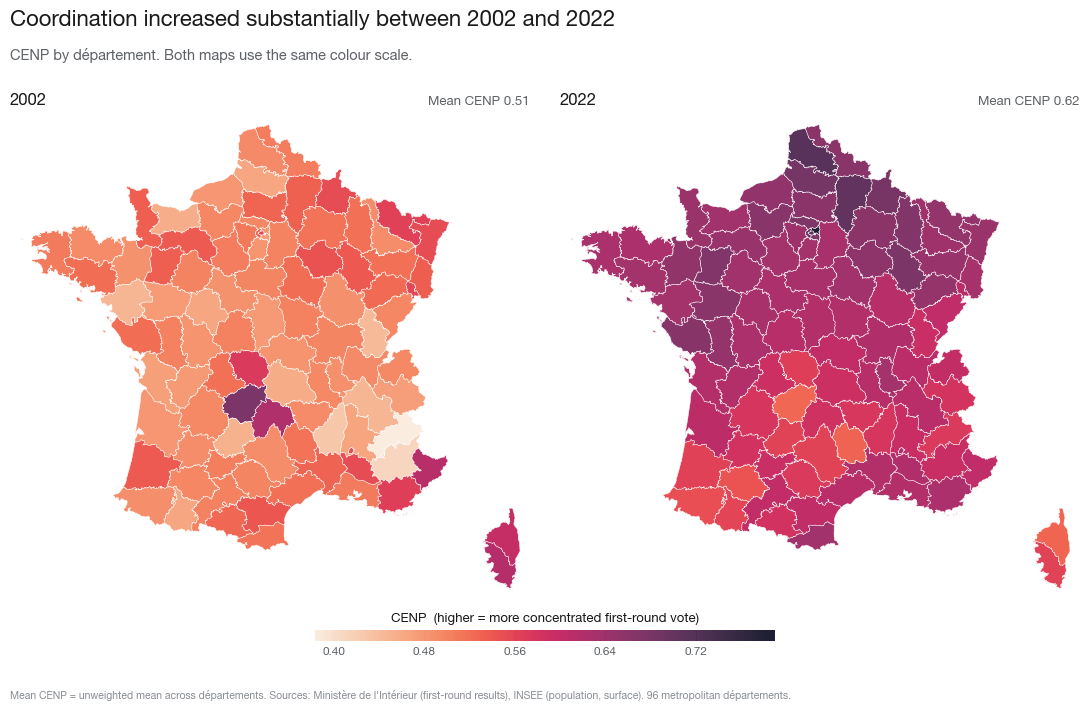

In [9]:
pooled_cenp = pd.concat([levels[year]["CENP"] for year in YEARS])
cenp_norm = Normalize(vmin=pooled_cenp.min(), vmax=pooled_cenp.max())

fig, axes, legend_box = report_figure(
    "Coordination increased substantially between 2002 and 2022",
    "CENP by département. Both maps use the same colour scale.",
    n_panels=2, map_width=DOUBLE_MAP_WIDTH, panel_headers=True,
    note="Mean CENP = unweighted mean across départements. " + SOURCE_NOTE)
for ax, year in zip(axes, YEARS):
    plot_continuous_department_map(levels[year], "CENP", ax, norm=cenp_norm)
    panel_header(ax, str(year), f"Mean CENP {levels[year]['CENP'].mean():.2f}")
add_colorbar(fig, legend_box, CMAP_LEVELS, cenp_norm, "CENP  (higher = more concentrated first-round vote)", width=4.6)
FIGURES["figure_1_cenp_departements_2002_2022"] = fig
plt.show()

## 8. Figure 2 — Change in coordination

`delta_CENP = CENP_2022 − CENP_2002`, diverging scale centred at 0 with symmetric limits. This is the change in the
observed concentration of the first-round vote, not a coordination *gain* (there is no sincere counterfactual).
The subtitle count and the callouts (two largest increases, two smallest changes, and Paris as a reference point) are
computed from the data.

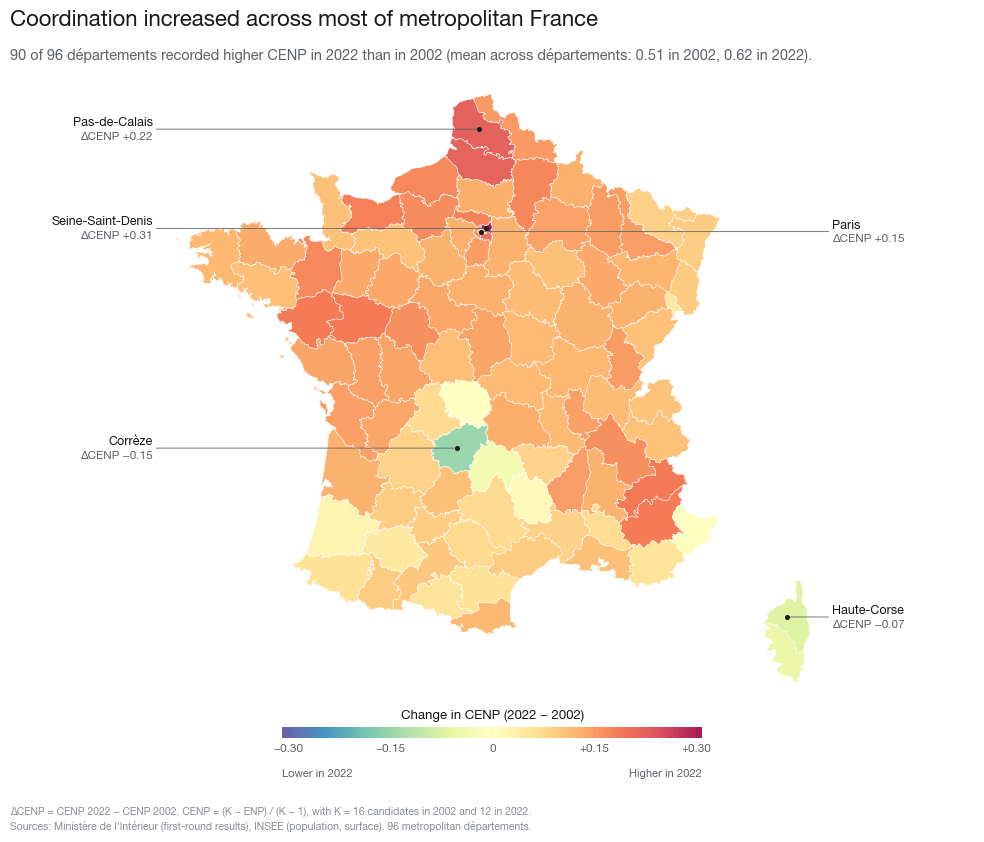

In [10]:
n_increase = int((change["delta_CENP"] > 0).sum())
mean_cenp = {year: levels[year]["CENP"].mean() for year in YEARS}
change_by_code = change.set_index("department_code")

fig, (ax,), legend_box = report_figure(
    "Coordination increased across most of metropolitan France",
    f"{n_increase} of {len(change)} départements recorded higher CENP in 2022 than in 2002 "
    f"(mean across départements: {mean_cenp[2002]:.2f} in 2002, {mean_cenp[2022]:.2f} in 2022).",
    gutter=CALLOUT_GUTTER, legend_height=1.0,
    note="ΔCENP = CENP 2022 − CENP 2002. CENP = (K − ENP) / (K − 1), with K = 16 candidates in 2002 and 12 in 2022.\n"
         + SOURCE_NOTE)
delta_norm = plot_diverging_department_map(change, "delta_CENP", ax)
add_callouts(ax, change, extreme_codes(change, "delta_CENP", extra=CALLOUT_REFERENCE_CODES),
             lambda code: (change_by_code.loc[code, "department_name"],
                           f"ΔCENP {signed(change_by_code.loc[code, 'delta_CENP'])}"),
             sides=CALLOUT_SIDES)
add_colorbar(fig, legend_box, CMAP_DIVERGING, delta_norm, "Change in CENP (2022 − 2002)", diverging=True,
             ends=("Lower in 2022", "Higher in 2022"))
FIGURES["figure_2_delta_cenp_departements"] = fig
plt.show()

## 9. Figure 3 — 2022 residual coordination relative to density

Residuals of the 2022 OLS `CENP ~ log_density` (estimated in §5, 96 metropolitan départements):
`residual = observed CENP − fitted CENP`.

* **positive** residual: the département is *more* coordinated than predicted by its density alone;
* **negative** residual: *less* coordinated than predicted by its density alone.

This is a **descriptive** decomposition, not a causal adjustment: the fitted line summarises the cross-département
association, and the residual collects everything else (regional traditions, candidates' home bases, the composition
of the electorate, …). The slope and R² below should match `analysis_departements.ipynb`.

In [11]:
print(residual_fit.summary().tables[1])
print(f"R² = {residual_fit.rsquared:.3f}, n = {int(residual_fit.nobs)}")
residual_table = residuals[["department_code", "department_name", "CENP", "fitted_CENP", "residual_CENP"]]
print("Largest positive residuals:")
show(residual_table.nlargest(5, "residual_CENP"))
print("Largest negative residuals:")
show(residual_table.nsmallest(5, "residual_CENP"))

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.5296      0.014     37.470      0.000       0.501       0.558
log_density     0.0198      0.003      6.770      0.000       0.014       0.026
R² = 0.328, n = 96
Largest positive residuals:


,department_code,department_name,CENP,fitted_CENP,residual_CENP
1,02,Aisne,0.705265,0.614102,0.091163
93,93,Seine-Saint-Denis,0.789987,0.705265,0.084722
52,52,Haute-Marne,0.676004,0.595098,0.080906
62,62,Pas-de-Calais,0.714548,0.636293,0.078255
7,08,Ardennes,0.681717,0.607477,0.074240


Largest negative residuals:


,department_code,department_name,CENP,fitted_CENP,residual_CENP
18,19,Corrèze,0.526279,0.603116,-0.076836
29,2B,Haute-Corse,0.528422,0.602479,-0.074058
64,64,Pyrénées-Atlantiques,0.549328,0.619017,-0.069689
48,48,Lozère,0.529610,0.582942,-0.053333
32,32,Gers,0.544529,0.597444,-0.052916


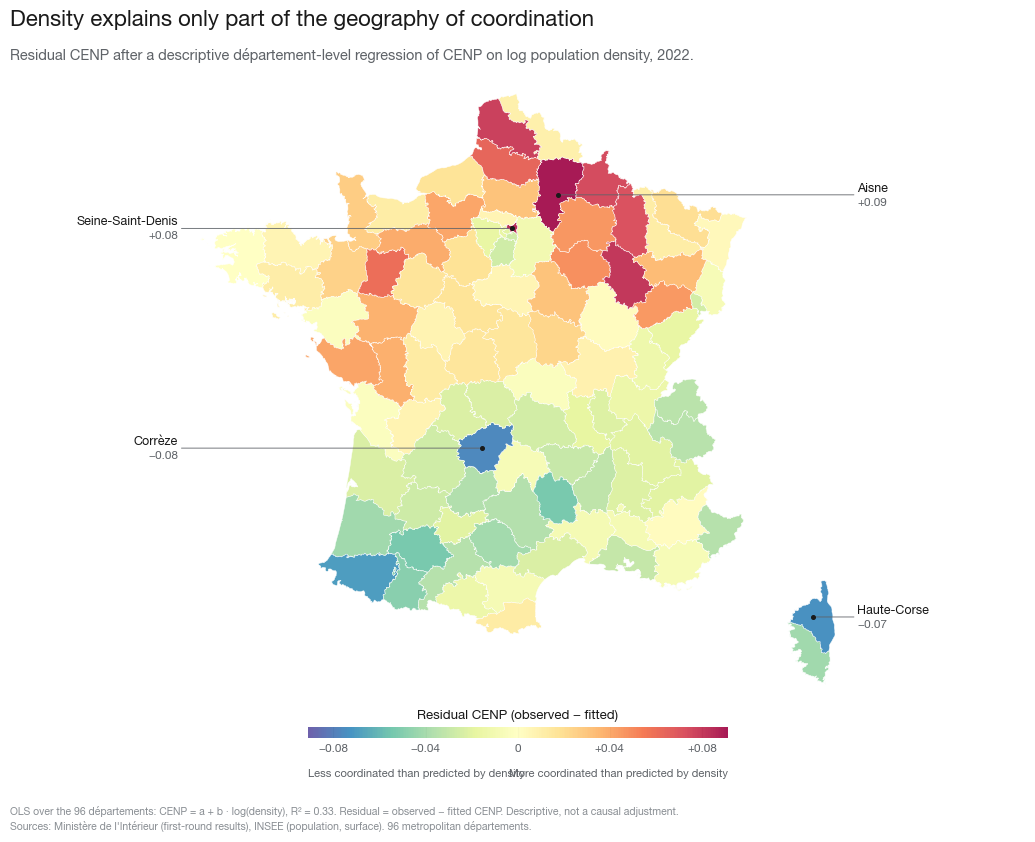

In [12]:
residual_by_code = residuals.set_index("department_code")


def residual_label(code):
    """Name and residual only: the colour-bar end labels say what positive and negative residuals mean."""
    return residual_by_code.loc[code, "department_name"], signed(residual_by_code.loc[code, "residual_CENP"])


fig, (ax,), legend_box = report_figure(
    "Density explains only part of the geography of coordination",
    "Residual CENP after a descriptive département-level regression of CENP on log population density, 2022.",
    gutter=CALLOUT_GUTTER + 0.04, legend_height=1.0,
    note=f"OLS over the 96 départements: CENP = a + b · log(density), R² = {residual_fit.rsquared:.2f}. "
         "Residual = observed − fitted CENP. Descriptive, not a causal adjustment.\n" + SOURCE_NOTE)
residual_norm = plot_diverging_department_map(residuals, "residual_CENP", ax)
add_callouts(ax, residuals, extreme_codes(residuals, "residual_CENP"), residual_label)
add_colorbar(fig, legend_box, CMAP_DIVERGING, residual_norm, "Residual CENP (observed − fitted)", diverging=True,
             ends=("Less coordinated than predicted by density", "More coordinated than predicted by density"))
FIGURES["figure_3_residual_cenp_2022"] = fig
plt.show()

## 10. Save figures

PNG (300 dpi) and PDF in `figures/`; only the three figures above are written (the cliff-location map is no longer part of the static set).

In [13]:
FIGURES_DIR.mkdir(exist_ok=True)
for name, fig in FIGURES.items():
    for extension in ("png", "pdf"):
        path = FIGURES_DIR / f"{name}.{extension}"
        fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.12, facecolor="white")
        print("Saved", path.relative_to(ROOT))

Saved figures/figure_1_cenp_departements_2002_2022.png
Saved figures/figure_1_cenp_departements_2002_2022.pdf
Saved figures/figure_2_delta_cenp_departements.png
Saved figures/figure_2_delta_cenp_departements.pdf
Saved figures/figure_3_residual_cenp_2022.png
Saved figures/figure_3_residual_cenp_2022.pdf
